## Odds Analysis and Prediction


## Description:
This project provides detailed historical sports betting data, including match results, team statistics, odds from multiple bookmakers, and outcomes across a range of sports and leagues. It is well-suited for machine learning applications in predictive modeling, enabling analysis of betting trends, win/loss probabilities, and strategy optimization. The dataset includes features such as team form, player performance, weather conditions, and pre-match odds. Ideal for developing classification or regression models, as well as evaluating and refining betting strategies using real-world data.

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


## Import dataset

In [2]:
df = pd.read_csv('sports_predictive_analysis.csv')

In [3]:
df.head()

,Match_ID,Date,Sport,Home_Team,Away_Team,Home_Team_Odds,Away_Team_Odds,Draw_Odds,Predicted_Winner,Actual_Winner
0,M00001,2024-01-24,Basketball,Gonzalezmouth Tigers,Hernandezfurt Lions,3.62,3.99,NaN,Hernandezfurt Lions,Hernandezfurt Lions
1,M00002,2025-05-03,Basketball,Rothstad Wolves,North Manuel Eagles,1.84,NaN,NaN,Rothstad Wolves,Rothstad Wolves
2,M00003,2025-04-10,Baseball,Aliciaport Lions,West Gabrielton Lions,3.93,3.29,NaN,Aliciaport Lions,Aliciaport Lions
3,M00004,2024-08-02,Tennis,Lake Samantha Eagles,Simonshire Lions,3.70,3.61,NaN,Simonshire Lions,Lake Samantha Eagles
4,M00005,2024-10-05,Tennis,Brendanport Eagles,Williamsfurt Bears,2.26,2.52,NaN,Williamsfurt Bears,Brendanport Eagles


In [4]:
df.tail()

,Match_ID,Date,Sport,Home_Team,Away_Team,Home_Team_Odds,Away_Team_Odds,Draw_Odds,Predicted_Winner,Actual_Winner
1364,M01365,2025-04-25,Tennis,Brewerstad Bears,Isaacview Bears,1.37,2.47,NaN,Brewerstad Bears,Brewerstad Bears
1365,M01366,2023-09-07,Tennis,New Raymond Lions,New Ashleeberg Lions,3.74,4.93,NaN,New Raymond Lions,New Ashleeberg Lions
1366,M01367,2025-06-18,Basketball,Lewisburgh Bears,Lake Kristinbury Tigers,2.32,2.30,NaN,Lewisburgh Bears,Lewisburgh Bears
1367,M01368,2024-02-18,Basketball,Billport Lions,West Catherinemouth Bears,4.24,2.19,NaN,West Catherinemouth Bears,West Catherinemouth Bears
1368,M01369,2024-02-01,Basketball,Andreaside Eagles,Smithborough Lions,3.66,4.23,NaN,Smithborough Lions,Smithborough Lions


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1369 entries, 0 to 1368
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Match_ID          1369 non-null   object 
 1   Date              1369 non-null   object 
 2   Sport             1369 non-null   object 
 3   Home_Team         1369 non-null   object 
 4   Away_Team         1369 non-null   object 
 5   Home_Team_Odds    1298 non-null   float64
 6   Away_Team_Odds    1282 non-null   float64
 7   Draw_Odds         498 non-null    float64
 8   Predicted_Winner  1369 non-null   object 
 9   Actual_Winner     1369 non-null   object 
dtypes: float64(3), object(7)
memory usage: 107.1+ KB


In [6]:
df.describe()

,Home_Team_Odds,Away_Team_Odds,Draw_Odds
count,1298.000000,1282.000000,498.000000
mean,3.069823,3.060031,3.103012
std,1.096600,1.087785,1.098248
min,1.200000,1.210000,1.200000
25%,2.110000,2.130000,2.142500
50%,3.080000,2.995000,3.160000
75%,3.980000,4.017500,4.062500
max,4.980000,5.000000,4.990000


In [7]:
df.isnull().sum()

Match_ID              0
Date                  0
Sport                 0
Home_Team             0
Away_Team             0
Home_Team_Odds       71
Away_Team_Odds       87
Draw_Odds           871
Predicted_Winner      0
Actual_Winner         0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

Match_ID             object
Date                 object
Sport                object
Home_Team            object
Away_Team            object
Home_Team_Odds      float64
Away_Team_Odds      float64
Draw_Odds           float64
Predicted_Winner     object
Actual_Winner        object
dtype: object

In [10]:
df.shape

(1369, 10)

In [11]:
df.columns

Index(['Match_ID', 'Date', 'Sport', 'Home_Team', 'Away_Team', 'Home_Team_Odds',
       'Away_Team_Odds', 'Draw_Odds', 'Predicted_Winner', 'Actual_Winner'],
      dtype='object')

## Data visualizations

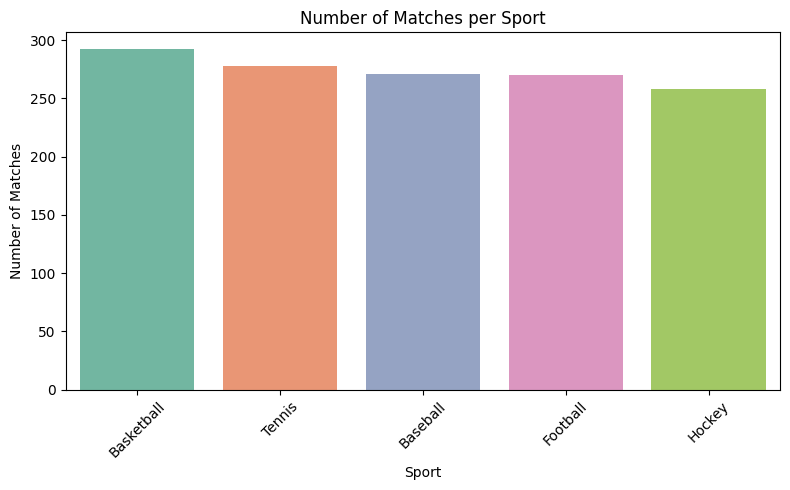

In [12]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Sport', order=df['Sport'].value_counts().index, palette='Set2')
plt.title('Number of Matches per Sport')
plt.xlabel('Sport')
plt.ylabel('Number of Matches')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [13]:
accuracy = (df['Predicted_Winner'] == df['Actual_Winner']).mean() * 100
print(f"Prediction Accuracy: {accuracy:.2f}%")


Prediction Accuracy: 43.97%


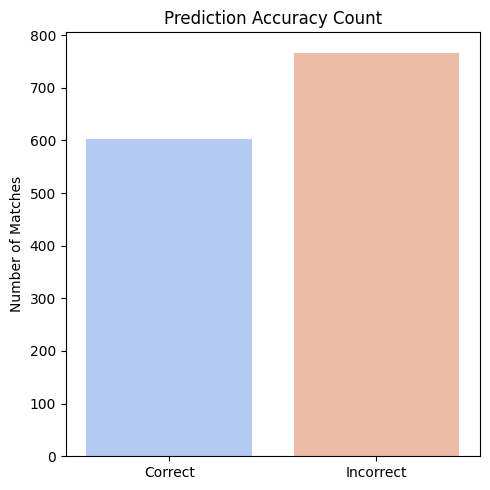

In [14]:
plt.figure(figsize=(5, 5))
sns.barplot(x=['Correct', 'Incorrect'],
            y=[(df['Predicted_Winner'] == df['Actual_Winner']).sum(),
               (df['Predicted_Winner'] != df['Actual_Winner']).sum()],
            palette='coolwarm')
plt.title('Prediction Accuracy Count')
plt.ylabel('Number of Matches')
plt.tight_layout()
plt.show()


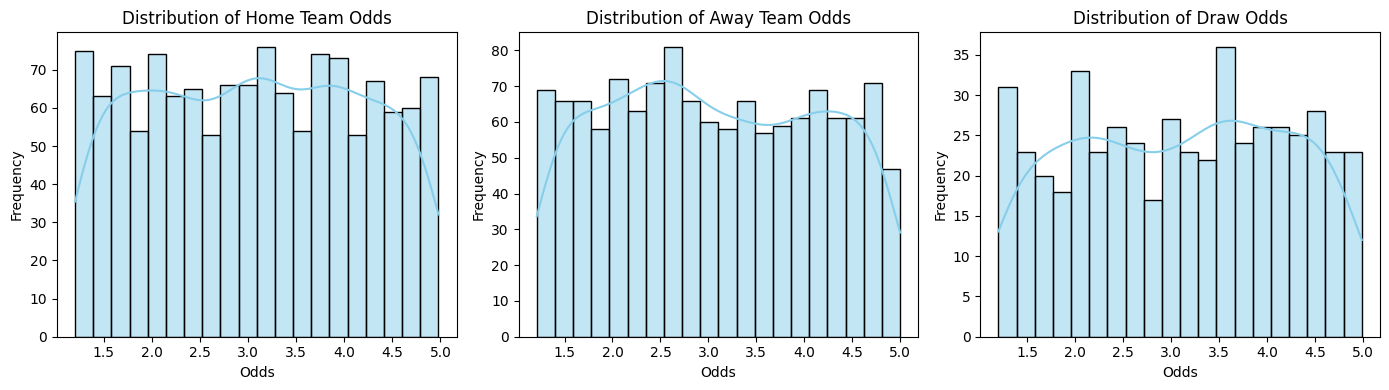

In [15]:
plt.figure(figsize=(14, 4))

for i, col in enumerate(['Home_Team_Odds', 'Away_Team_Odds', 'Draw_Odds']):
    plt.subplot(1, 3, i+1)
    sns.histplot(df[col], bins=20, kde=True, color='skyblue')
    plt.title(f'Distribution of {col.replace("_", " ")}')
    plt.xlabel('Odds')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


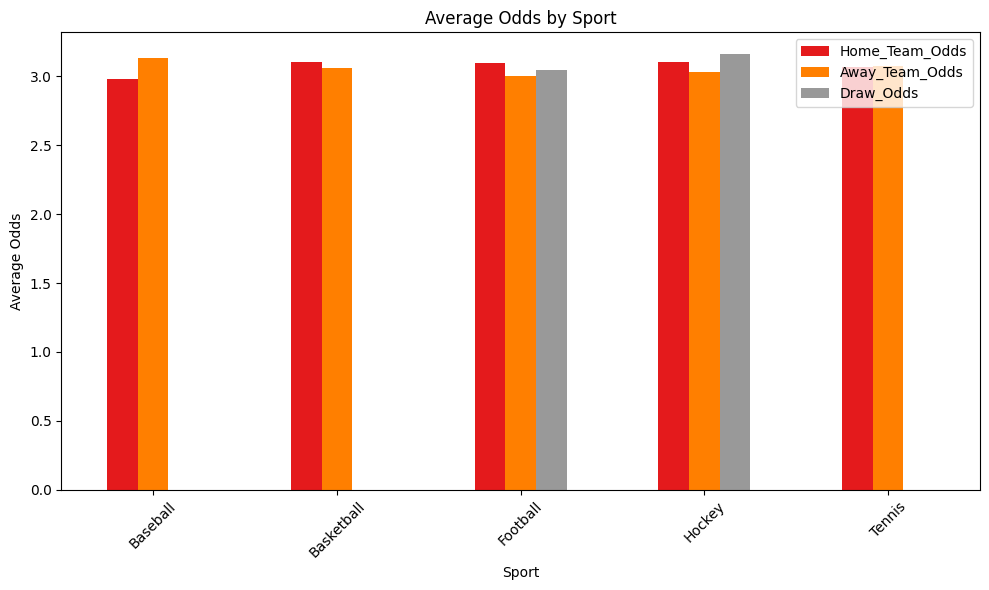

In [16]:
avg_odds = df.groupby('Sport')[['Home_Team_Odds', 'Away_Team_Odds', 'Draw_Odds']].mean().reset_index()

avg_odds.plot(x='Sport', kind='bar', figsize=(10, 6), stacked=False, colormap='Set1')
plt.title('Average Odds by Sport')
plt.xlabel('Sport')
plt.ylabel('Average Odds')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


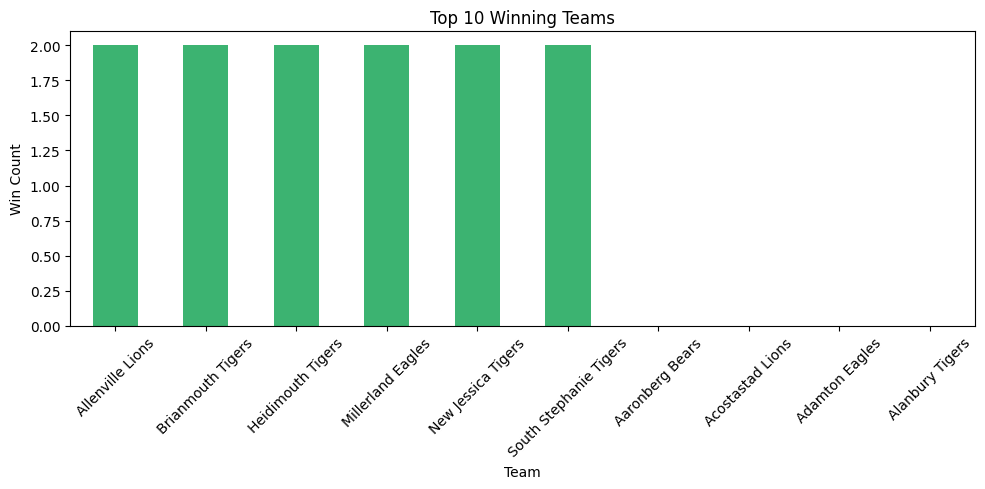

In [17]:
home_wins = df[df['Actual_Winner'] == df['Home_Team']]['Home_Team'].value_counts()
away_wins = df[df['Actual_Winner'] == df['Away_Team']]['Away_Team'].value_counts()

team_wins = (home_wins + away_wins).sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
team_wins.plot(kind='bar', color='mediumseagreen')
plt.title('Top 10 Winning Teams')
plt.ylabel('Win Count')
plt.xlabel('Team')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Predictive modeling

### First, the right question

The original version of this notebook tried to predict `Actual_Winner` directly — i.e. *which specific team* won, out of the hundreds of distinct team names in the data. That is the wrong target for two reasons:

1. **It's a many-hundred-class problem.** With ~1,300 matches spread across hundreds of unique teams, most teams appear only a handful of times, so "predict the exact winning team" is close to impossible and the accuracy came out at 3–9%.
2. **The label encoding was broken.** `Home_Team`, `Away_Team`, and `Actual_Winner` were each label-encoded with a *separate* `LabelEncoder.fit_transform`, so the integer for a team as `Actual_Winner` did **not** match the integer for the same team as `Home_Team`/`Away_Team`. The model literally could not learn "the winner is the home team" because those live in different integer spaces.

The question a betting dataset can actually answer is: **what was the outcome — home win (H), away win (A), or draw (D)?** That's a clean 3-class problem, and the natural predictors are the odds.


In [18]:
# Reload cleanly (the EDA cells above are non-destructive, but re-run this to be safe)
df = pd.read_csv('sports_predictive_analysis.csv')

# Derive the OUTCOME from the result, not the specific team
def to_outcome(row):
    if row['Actual_Winner'] == row['Home_Team']:
        return 'H'
    if row['Actual_Winner'] == row['Away_Team']:
        return 'A'
    return 'D'

df['Outcome'] = df.apply(to_outcome, axis=1)
df['Outcome'].value_counts(normalize=True).round(3)


Outcome
H    0.451
A    0.419
D    0.131
Name: proportion, dtype: float64

### Does the data actually contain any signal?

Before fitting a single model, the most important check: do the odds carry any information about the outcome at all? If bookmaker odds mean anything, the home team should have *lower* odds in matches it wins than in matches it loses (a favourite is priced shorter). Let's look.

In [19]:
sub = df.dropna(subset=['Home_Team_Odds', 'Away_Team_Odds']).copy()

print('Mean Home_Team_Odds when the home team WINS: ',
      round(sub.loc[sub.Outcome == 'H', 'Home_Team_Odds'].mean(), 3))
print('Mean Home_Team_Odds when the home team does NOT win:',
      round(sub.loc[sub.Outcome != 'H', 'Home_Team_Odds'].mean(), 3))

# How often does the favourite (the side with the lower odds) actually win?
sub['favourite'] = np.where(sub.Home_Team_Odds < sub.Away_Team_Odds, 'H', 'A')
fav_win_rate = (sub.favourite == sub.Outcome).mean() * 100
print(f'\nFavourite (lower odds) win rate: {fav_win_rate:.2f}%')
print(f'Home-win base rate:              {(df.Outcome == "H").mean()*100:.2f}%')


Mean Home_Team_Odds when the home team WINS:  3.056
Mean Home_Team_Odds when the home team does NOT win: 3.061

Favourite (lower odds) win rate: 43.09%
Home-win base rate:              45.07%


**The odds carry no signal.** The average home-team odds are essentially identical whether the home team wins or not (~3.06 either way), and the favourite wins at almost exactly the home-win base rate — i.e. picking the "favourite" is no better than always picking the home team. This is a synthetic dataset (note the procedurally generated team names like "Gonzalezmouth Tigers"), and the odds were evidently assigned without any real relationship to the outcomes. That's a fine thing to *discover* — but it means we should expect the accuracy ceiling to be the base rate, and no model should beat it. Let's confirm that rigorously.

### Modeling, done correctly, with honest baselines

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, log_loss
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier


In [21]:
# Features: the odds only (the sole plausible signal). Median-impute the
# missing values (Draw_Odds in particular is missing for most rows).
features = ['Home_Team_Odds', 'Away_Team_Odds', 'Draw_Odds']
X = df[features].fillna(df[features].median())
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print('train:', X_train.shape, '  test:', X_test.shape)


train: (1095, 3)   test: (274, 3)


In [22]:
# Baseline 1: always predict the most common outcome (majority class).
# This is the number every real model must beat to be worth anything.
majority = DummyClassifier(strategy='most_frequent').fit(X_train, y_train)
maj_acc = accuracy_score(y_test, majority.predict(X_test)) * 100
print(f'Baseline (always predict "{y_train.mode()[0]}"): {maj_acc:.2f}%')


Baseline (always predict "H"): 44.89%


In [23]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Naive Bayes': GaussianNB(),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Support Vector Machine': SVC(probability=True, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test)) * 100
    ll = log_loss(y_test, model.predict_proba(X_test))
    results[name] = {'accuracy': acc, 'log_loss': ll}

results_df = pd.DataFrame(results).T
results_df.loc['Baseline (majority class)'] = [maj_acc, np.nan]
results_df.round(3).sort_values('accuracy', ascending=False)


,accuracy,log_loss
Decision Tree,45.985,18.953
Support Vector Machine,45.620,0.971
Random Forest,45.255,1.128
Baseline (majority class),44.891,NaN
Naive Bayes,43.796,0.986
K-Nearest Neighbors,43.431,2.929
Logistic Regression,41.241,0.993


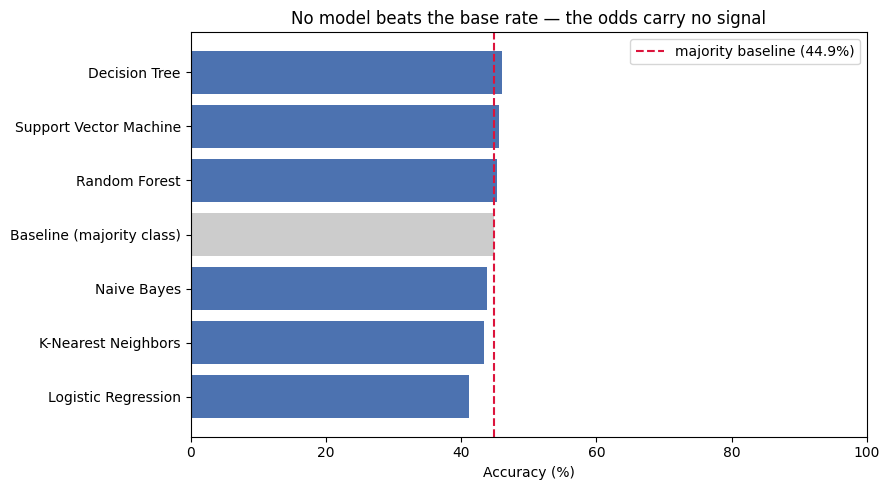

In [24]:
plt.figure(figsize=(9, 5))
order = results_df['accuracy'].sort_values()
colors = ['#cccccc' if name == 'Baseline (majority class)' else '#4c72b0' for name in order.index]
plt.barh(order.index, order.values, color=colors)
plt.axvline(maj_acc, color='crimson', linestyle='--', label=f'majority baseline ({maj_acc:.1f}%)')
plt.xlabel('Accuracy (%)')
plt.title('No model beats the base rate \u2014 the odds carry no signal')
plt.legend()
plt.xlim(0, 100)
plt.tight_layout()
plt.show()


## Conclusion

Framed correctly (predict the H/A/D outcome, not which specific team wins), the models land right around the **majority-class base rate of ~45%** — some slightly below it, the best barely above. None of them meaningfully beats *always guessing "home win"*, which requires no data at all.

That isn't a modelling failure to be fixed with a better algorithm or more tuning — it's a property of the data. This is a **synthetic dataset** whose odds were generated without any real relationship to its outcomes, so there is simply no signal to learn. The honest result is: *you cannot predict these outcomes from these odds, because the odds are noise.*

The original notebook's 3–9% accuracy was a symptom of asking the wrong question (predict one of hundreds of exact team names, with a broken label encoding on top). Asking the right question doesn't rescue the prediction — nothing can, on this data — but it does reveal the real ceiling and *why* it's there, which is the actual point of the exercise.

If you want to redo this on data where the odds mean something, use a real historical odds source (e.g. football-data.co.uk) rather than a synthetic generator, and evaluate with log-loss against the de-vigged bookmaker probabilities — see the companion project *Bundesliga-Match-Analysis-and-Prediction* for that done end to end.